## Code to add boolean to the saturation bursts based on the '∗' symbol in the table

#### The code retrieves the burst IDs where saturation is marked, then imports the .csv file and add an extra boolean column to add a saturation tag

There are a total of 197 bursts
Code ran on March-12

In [45]:
import pdfplumber
import re
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
def extract_saturated_bursts(pdf_path, print_formatted=True):
    """
    Extract burst IDs that have a saturation symbol '∗' in their peak flux column
    from a PDF table.

    Parameters
    ----------
    pdf_path : str
        Path to the PDF file containing burst data.
    print_formatted : bool, optional, default=True
        If True, prints the list of saturated burst IDs in a nicely formatted block.

    Returns
    -------
    list of str
        Sorted list of unique burst IDs (e.g., 'B12345') that are marked as saturated.

    Notes
    -----
    - Looks for burst IDs in the format 'B' followed by 5 digits (Bxxxxx).
    - Uses `pdfplumber` to extract text from each page of the PDF.
    - Lines containing the '∗' symbol are considered saturated bursts.
    - The returned list is sorted numerically by burst number.
    """

    # Initialize empty list to store IDs of saturated bursts
    saturated_bursts = []

    # Regex pattern to match burst IDs of the form 'B12345'
    burst_pattern = re.compile(r"B\d{5}")

    # Open the PDF and iterate through each page
    with pdfplumber.open(pdf_path) as pdf:
        # tqdm provides a progress bar for the PDF scanning process
        for page in tqdm(pdf.pages, desc="Scanning PDF for saturation"):

            # Extract text from the current page
            text = page.extract_text()
            if text is None:  # Skip page if no text found
                continue

            # Process the page line by line
            for line in text.split("\n"):

                # Check if the line contains the saturation symbol
                if "∗" in line:
                    # Search for a burst ID in the line
                    match = burst_pattern.search(line)

                    if match:
                        # Add the burst ID to the list
                        saturated_bursts.append(match.group())

    # Remove duplicates and sort numerically by the number part of the burst ID
    saturated_bursts = sorted(set(saturated_bursts), key=lambda x: int(x[1:]))

    # Return the list of unique, sorted saturated burst IDs
    return saturated_bursts

In [42]:
saturated_bursts = extract_saturated_bursts("../databases/fast_zhang_2025/FRB20240114A_SuppTab2.pdf")

Scanning PDF for saturation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 232/232 [00:53<00:00,  4.37it/s]


,BurstID,Date,MJD,MJD(bary@inf freq.),DM,DMError,width,widtherror,flux,fluxerror,...,Upper_freq_err(MHz),Tsamp(s),Nchan,fluence_mJyms,fluenceerror,energy,energyerror,note,bestfit,saturation_tag
85,B00086,20240221,60361.188547,60361.184186,528.1,0.1,3.14,0.05,3185.51,151.53,...,1.0,0.000049,4096,9998.32,501.68,2.111670e+39,1.061000e+38,high RFI,CDF,True
127,B00128,20240305,60374.190175,60374.186065,530.2,2.6,2.47,0.10,1956.61,92.88,...,1.0,0.000098,8192,4826.74,299.22,8.985320e+38,6.572680e+37,NaN,CDF,True
143,B00144,20240305,60374.191294,60374.187184,528.3,0.1,4.82,0.10,973.52,44.95,...,2.7,0.000098,8192,4694.03,237.14,9.909900e+38,5.037490e+37,NaN,CDF,True
170,B00171,20240305,60374.193674,60374.189564,531.7,1.8,1.63,0.10,1278.87,62.10,...,0.9,0.000098,8192,2084.01,161.43,3.124550e+38,2.435830e+37,NaN,CDF,True
195,B00196,20240305,60374.195797,60374.191688,529.3,0.2,0.99,0.10,780.28,38.11,...,0.8,0.000098,8192,776.16,85.59,1.439600e+38,1.615090e+37,NaN,CDF,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10533,B10534,20240727,60517.829890,60517.836103,531.3,0.4,8.81,0.06,1187.50,94.49,...,0.8,0.000049,4096,10456.45,834.88,1.750910e+39,1.482540e+38,NaN,CDF,True
10575,B10576,20240727,60517.836211,60517.842424,528.5,0.1,1.13,0.05,2695.60,213.80,...,1.1,0.000049,4096,3053.08,276.08,6.354710e+38,5.772190e+37,NaN,CDF,True
10674,B10675,20240728,60518.753965,60518.760208,524.7,0.2,5.02,0.05,697.32,42.13,...,5.6,0.000049,4096,3501.74,214.93,4.815340e+38,3.336700e+37,NaN,CDF,True
10876,B10877,20240729,60519.783857,60519.790134,529.2,0.4,9.21,0.06,877.31,47.76,...,1.0,0.000049,4096,8077.86,442.55,1.696100e+39,9.345470e+37,NaN,CDF,True


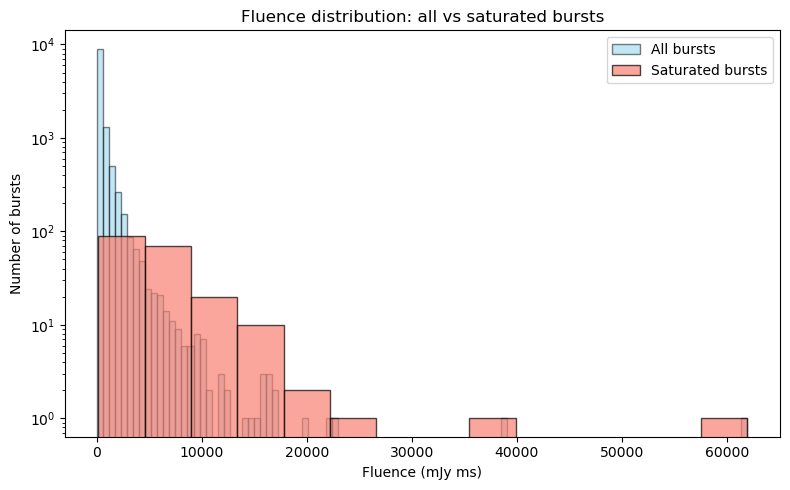

In [50]:
def add_saturation_tag(saturated_bursts, csv_file):
    """
    Read in csv FAST .csv file  
    from: https://ui.adsabs.harvard.edu/abs/2025arXiv250714707Z/abstract
    host: https://doi.org/10.57760/sciencedb.Fastro.00030

    Add a boolean 'saturation_tag' column to the FAST dataframe.

    Parameters
    ----------
    fast_csv : pd.DataFrame
        The FAST bursts dataframe as returned by fast_zhang_2024().
    saturated_bursts : list of str
        List of burst IDs that are saturated (from extract_saturated_bursts).

    Returns
    -------
    pd.DataFrame
        The original dataframe with an extra 'saturation_tag' column
        where True indicates a saturated burst.
    """

    #Read CSV normally (don't set index_col)
    fast_csv = pd.read_csv(csv_file, sep=",", header=0, na_values='NA')
    
    # Rename measurement columns only (keep BurstID and Date as-is)
    fast_csv = fast_csv.rename(columns={
        "MJD(topo@1.5GHz)": "MJD",
        "DM(pc/cc)": "DM",
        "DM_err(pc/cc)": "DMError",
        "Weff(ms)": "width",
        "Weff_err(ms)": "widtherror",
        "Flux(mJy)": "flux",
        "Flux_err(mJy)": "fluxerror",
        "Bandwidth(MHz)": "bandwidth",
        "Bandwidth_err(MHz)": "bandwidtherror",
        "Fluence(mJy ms)": "fluence_mJyms",
        "Fluence_err(mJy ms)": "fluenceerror",
        "Energy(erg)": "energy",
        "Energy_err(erg)": "energyerror",
        "Center_Freq.(MHz)": "feakfrequency",
        "Center_Freq_err(MHz)": "feakfrequencyerror"
    })
    
    # Create a new column 'saturation_tag', True if BurstID is in saturated_bursts
    fast_csv['saturation_tag'] = fast_csv['BurstID'].isin(saturated_bursts)

    saturated_df = fast_csv[fast_csv['saturation_tag']]
    display(saturated_df)

    name_csv = "FRB20240114A_SuppTab2_saturation_tag.csv"
    fast_csv.to_csv(name_csv, header=True, index=True, na_rep='NA')

    # Extract fluence for the full sample and saturated bursts
    fluence_all = fast_csv['fluence_mJyms'].dropna()
    fluence_saturated = fast_csv.loc[fast_csv['saturation_tag'], 'fluence_mJyms'].dropna()

    # Plotting
    plt.figure(figsize=(8,5))
    plt.hist(fluence_all, bins="sqrt", alpha=0.5, label='All bursts', color='skyblue', edgecolor='black')
    plt.hist(fluence_saturated, bins="sqrt", alpha=0.7, label='Saturated bursts', color='salmon', edgecolor='black')
    plt.xlabel("Fluence (mJy ms)")
    plt.ylabel("Number of bursts")
    plt.title("Fluence distribution: all vs saturated bursts")
    plt.legend()
    
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return fast_csv

fast_csv = add_saturation_tag(saturated_bursts, csv_file="../databases/fast_zhang_2025/FRB20240114A_SuppTab2.csv")

In [51]:
import matplotlib.pyplot as plt

def plot_fluence_distribution_normalized(fast_csv, bins=30, log_scale=False):
    """
    Plot the normalized distribution of fluence for the full FAST sample
    and the saturated bursts.

    Parameters
    ----------
    fast_csv : pd.DataFrame
        FAST dataframe with 'fluence_mJyms' and 'saturation_tag' columns.
    bins : int, optional, default=30
        Number of bins in the histogram.
    log_scale : bool, optional, default=False
        If True, use logarithmic y-axis.
    """
    if 'saturation_tag' not in fast_csv.columns:
        raise ValueError("DataFrame does not have a 'saturation_tag' column. "
                         "Run add_saturation_tag() first.")

    # Extract fluence for the full sample and saturated bursts
    fluence_all = fast_csv['fluence_mJyms'].dropna()
    fluence_saturated = fast_csv.loc[fast_csv['saturation_tag'], 'fluence_mJyms'].dropna()

    # Plotting normalized histograms
    plt.figure(figsize=(8,5))
    plt.hist(fluence_all, bins=bins, alpha=0.5, label='All bursts',
             color='skyblue', edgecolor='black', density=True)
    plt.hist(fluence_saturated, bins=bins, alpha=0.7, label='Saturated bursts',
             color='salmon', edgecolor='black', density=True)
    
    plt.xlabel("Fluence (mJy ms)")
    plt.ylabel("Normalized density")
    plt.title("Normalized fluence distribution: all vs saturated bursts")
    plt.legend()
    
    if log_scale:
        plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

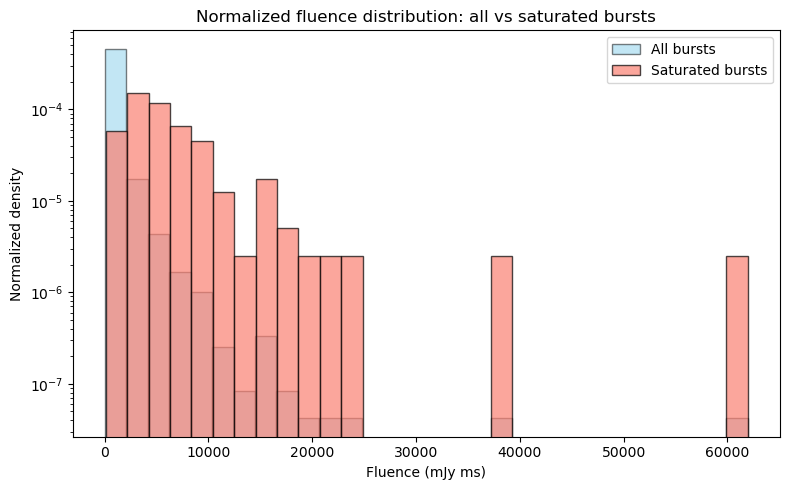

In [52]:
plot_fluence_distribution_normalized(fast_csv, bins=30, log_scale=True)

Just showing how many of the saturated bursts are high energy